# Summary
This notebook trains a small word-level language model on the Tiny Shakespeare dataset and then uses it to generate text.

## Install dependencies
Install the Python packages used in the notebook: PyTorch for the model and NumPy/Matplotlib for numerical work and plotting.

In [9]:
# uncomment if the following packages are not installed
# pip install torch matplotlib numpy

## Load the text corpus
Download the Tiny Shakespeare dataset and prints basic size statistics so we know what data the model will learn from.

In [10]:
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "tinyshakespeare.txt"

urllib.request.urlretrieve(url, filename)

with open(filename, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Length of dataset in characters: {len(text):,}")
print(f"Number of words in dataset: {len(text.split()):,}\n")

print(f"First 200 characters:\n{text[:200]}")

Length of dataset in characters: 1,115,394
Number of words in dataset: 202,651

First 200 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## Build the word vocabulary
Find every unique word in the corpus and create lookup tables for encoding words as integers and decoding integers back to text.

In [11]:
words = text.split()

unique_words = ["<PAD>"] + sorted(set(words))
vocab_size = len(unique_words)

stoi = {w: i for i, w in enumerate(unique_words)}
itos = {i: w for w, i in stoi.items()}

def encode(word):
    return stoi[word]

def decode(ids):
    return " ".join(itos[int(i)] for i in ids if itos[int(i)] != "<PAD>")

print(f"Vocabulary size: {vocab_size}")

print(f"Number of words/tokens: {len(words)}")

Vocabulary size: 25671
Number of words/tokens: 202651


## Create training examples
Turn the ordered word sequence into supervised examples where a fixed-length context predicts the next word, then split those examples into train, validation, and test sets.

In [12]:
import torch
# build the dataset
block_size = 20  # context length: how many words do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []

    context = [stoi["<PAD>"]] * block_size

    for w in words:
        X.append(context)
        Y.append(stoi[w])
        context = context[1:] + [stoi[w]]

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X, Y

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])      # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:])     # 10%

print(f"shape(Xtr): {tuple(Xtr.shape)}")
print(f"shape(Ytr): {tuple(Ytr.shape)}")

shape(Xtr): (162120, 20)
shape(Ytr): (162120,)


## Define the neural network
Next, we define a small feed-forward word model. It embeds the words in the current context, flattens those embeddings, and maps them to logits for next-token prediction.

In [13]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, vocab_size, block_size, embedding_size, layer_sizes):
        super().__init__()
        self.block_size = block_size
        self.vocab_size = vocab_size

        layers = [torch.nn.Embedding(vocab_size, embedding_size), torch.nn.Flatten()]
        input_size = block_size * embedding_size
        for hidden_size in layer_sizes:
            layers.extend([torch.nn.Linear(input_size, hidden_size), torch.nn.ReLU()])
            input_size = hidden_size
        layers.append(torch.nn.Linear(input_size, vocab_size))
        self.layers = torch.nn.Sequential(*layers)

    def forward(self, x):
        # Embedding layers require integer token indices.
        return self.layers(x.long())

    def loss(self, x, y):
        logits = self.forward(x)
        loss = torch.nn.functional.cross_entropy(logits, y.long())
        return loss


## Train and evaluate the model
Instantiate the network, train it with Adam, record the training loss, plot the loss curve, and report validation loss on the development split.

Number of parameters: 10670535
Network architecture:
NeuralNetwork(
  (layers): Sequential(
    (0): Embedding(25671, 128)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=2560, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=25671, bias=True)
  )
)
epoch  1 | loss 7.9129


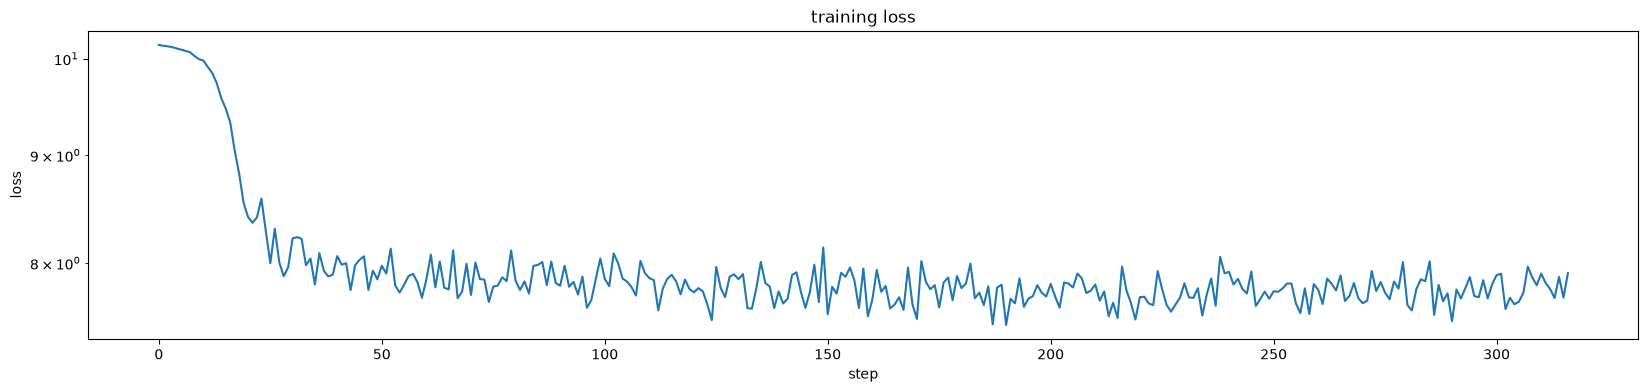

dev loss: 7.7941


In [14]:
layer_sizes = [256, 256, 256]
embedding_size = 128
net = NeuralNetwork(vocab_size, block_size, embedding_size, layer_sizes)

print(f"Number of parameters: {sum(p.numel() for p in net.parameters())}")
print(f"Network architecture:\n{net}")

optimizer = torch.optim.Adam(net.parameters(), lr=5e-4)
batch_size = 512
num_epochs = 1
lossi = []

for epoch in range(num_epochs):
    permutation = torch.randperm(Xtr.shape[0])
    for step in range(0, Xtr.shape[0], batch_size):
        indices = permutation[step:step + batch_size]
        xb = Xtr[indices]
        yb = Ytr[indices]

        # forward + backward + optimize
        loss = net.loss(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        lossi.append(loss.item())

    print(f"epoch {epoch + 1:2d} | loss {loss.item():.4f}")

# Evaluate in batches so the full vocabulary logits do not exhaust memory.
with torch.no_grad():
    dev_losses = []
    for step in range(0, Xdev.shape[0], batch_size):
        xb = Xdev[step:step + batch_size]
        yb = Ydev[step:step + batch_size]
        dev_losses.append(net.loss(xb, yb) * len(xb))
    dev_loss = torch.stack(dev_losses).sum() / len(Xdev)

%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))
plt.plot(lossi)
plt.yscale('log')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('training loss')
plt.show()

print(f"dev loss: {dev_loss.item():.4f}")

## Generate text from the model
Sample one word at a time from the trained model, feeding each sampled word back into the context to produce new text.

In [15]:
@torch.no_grad()
def generate_text(net, start_text='First Citizen:', max_new_words=100):
    net.eval()
    device = next(net.parameters()).device
    context = [stoi["<PAD>"]] * block_size

    start_words = start_text.split()
    unknown_words = [word for word in start_words if word not in stoi]
    if unknown_words:
        raise ValueError(f"Words not in vocabulary: {unknown_words}")

    generated_ids = [stoi[word] for word in start_words]

    for ix in generated_ids:
        context = context[1:] + [ix]

    for _ in range(max_new_words):
        x = torch.tensor([context], dtype=torch.long, device=device)
        logits = net(x)
        logits[0, stoi["<PAD>"]] = -torch.inf
        probs = torch.softmax(logits, dim=-1)[0]
        ix = torch.multinomial(probs, num_samples=1).item()

        generated_ids.append(ix)
        context = context[1:] + [ix]

    return decode(generated_ids)

print(generate_text(net, start_text='First Citizen:', max_new_words=100))

First Citizen: so myself, to This have betray safe blaze found fancy: in the No truth: speak VOLUMNIA: friend, the divided my your if not cloaks; I and their RICHARD even to ROMEO: o' of not thy embraces talk weighs body, My them With Warwick; hear, our isle, speak wilt he What here and Custom his Good sleep is And for and your swear swine this so expecting let country a Jack not steps. And Better given Tower, And should fear, Edward, the Tread ire, I your aught sour to tell to feigned sting Say, means rest, knacks: Warwick's were Brother, to
